# 📊 Data Analyst - EDA (Exploratory Data Analysis)
**Nama:** Naufal Adli  
**Tugas:** Data Analyst - Visualisasi EDA (Heatmap Korelasi & Grafik Distribusi Membership)  
**Dataset:** E-commerce Customer Behavior

## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
palette = sns.color_palette('viridis', 3)

# Load data mentah & data cleaned
df_raw = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')
df = pd.read_csv('E-commerce Customer Behavior Cleaned.csv')

print("=" * 60)
print("DATA MENTAH (Sebelum Cleaning oleh Oktavia)")
print("=" * 60)
print(f"Jumlah Baris : {df_raw.shape[0]}")
print(f"Jumlah Kolom : {df_raw.shape[1]}")
print(f"Kolom        : {list(df_raw.columns)}")
print(f"\nMissing Values:\n{df_raw.isnull().sum()}")
print(f"\nTipe Data:\n{df_raw.dtypes}")

DATA MENTAH (Sebelum Cleaning oleh Oktavia)
Jumlah Baris : 350
Jumlah Kolom : 11
Kolom        : ['Customer ID', 'Gender', 'Age', 'City', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level']

Missing Values:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

Tipe Data:
Customer ID                   int64
Gender                       object
Age                           int64
City                         object
Membership Type              object
Total Spend                 float64
Items Purchased               int64
Average Rating              float64
Discount Applied               bool
Days Since Last Purchase  

## 2. Ringkasan Data Setelah Cleaning

In [2]:
print("=" * 60)
print("DATA CLEANED (Hasil Pengerjaan Oktavia)")
print("=" * 60)
print(f"Jumlah Baris : {df.shape[0]} (dari {df_raw.shape[0]}, 2 baris dihapus karena missing value)")
print(f"Jumlah Kolom : {df.shape[1]} (dari {df_raw.shape[1]}, bertambah karena One-Hot Encoding City)")
print(f"\nKolom: {list(df.columns)}")
print(f"\nMissing Values: {df.isnull().sum().sum()} (sudah bersih)")

print("\n--- Mapping Encoding yang dilakukan Oktavia ---")
print("Gender       : Female=0, Male=1 (Label Encoding)")
print("Discount     : False=0, True=1 (Label Encoding)")
print("Membership   : Bronze=1, Silver=2, Gold=3 (Ordinal Encoding)")
print("Satisfaction : Unsatisfied=0, Neutral=1, Satisfied=2 (Ordinal Encoding)")
print("City         : One-Hot Encoding (6 kolom dummy)")

print("\n--- Statistik Deskriptif ---")
df.describe().round(2)

DATA CLEANED (Hasil Pengerjaan Oktavia)
Jumlah Baris : 348 (dari 350, 2 baris dihapus karena missing value)
Jumlah Kolom : 15 (dari 11, bertambah karena One-Hot Encoding City)

Kolom: ['Gender', 'Age', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level', 'City_Chicago', 'City_Houston', 'City_Los Angeles', 'City_Miami', 'City_New York', 'City_San Francisco']

Missing Values: 0 (sudah bersih)

--- Mapping Encoding yang dilakukan Oktavia ---
Gender       : Female=0, Male=1 (Label Encoding)
Discount     : False=0, True=1 (Label Encoding)
Membership   : Bronze=1, Silver=2, Gold=3 (Ordinal Encoding)
Satisfaction : Unsatisfied=0, Neutral=1, Satisfied=2 (Ordinal Encoding)
City         : One-Hot Encoding (6 kolom dummy)

--- Statistik Deskriptif ---


,Gender,Age,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,City_Chicago,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco
count,348.0,348.00,348.00,348.00,348.00,348.00,348.0,348.00,348.00,348.00,348.00,348.00,348.00,348.00,348.00
mean,0.5,33.58,2.01,847.79,12.63,4.02,0.5,26.61,1.03,0.17,0.16,0.17,0.17,0.17,0.17
std,0.5,4.88,0.82,361.69,4.15,0.58,0.5,13.47,0.83,0.37,0.37,0.38,0.37,0.38,0.37
min,0.0,26.00,1.00,410.80,7.00,3.00,0.0,9.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.0,30.00,1.00,505.75,9.00,3.50,0.0,15.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.0,32.00,2.00,780.20,12.00,4.10,1.0,23.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.0,37.00,3.00,1160.60,15.00,4.50,1.0,38.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.0,43.00,3.00,1520.10,21.00,4.90,1.0,63.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00


## 3. Distribusi Variabel Numerik

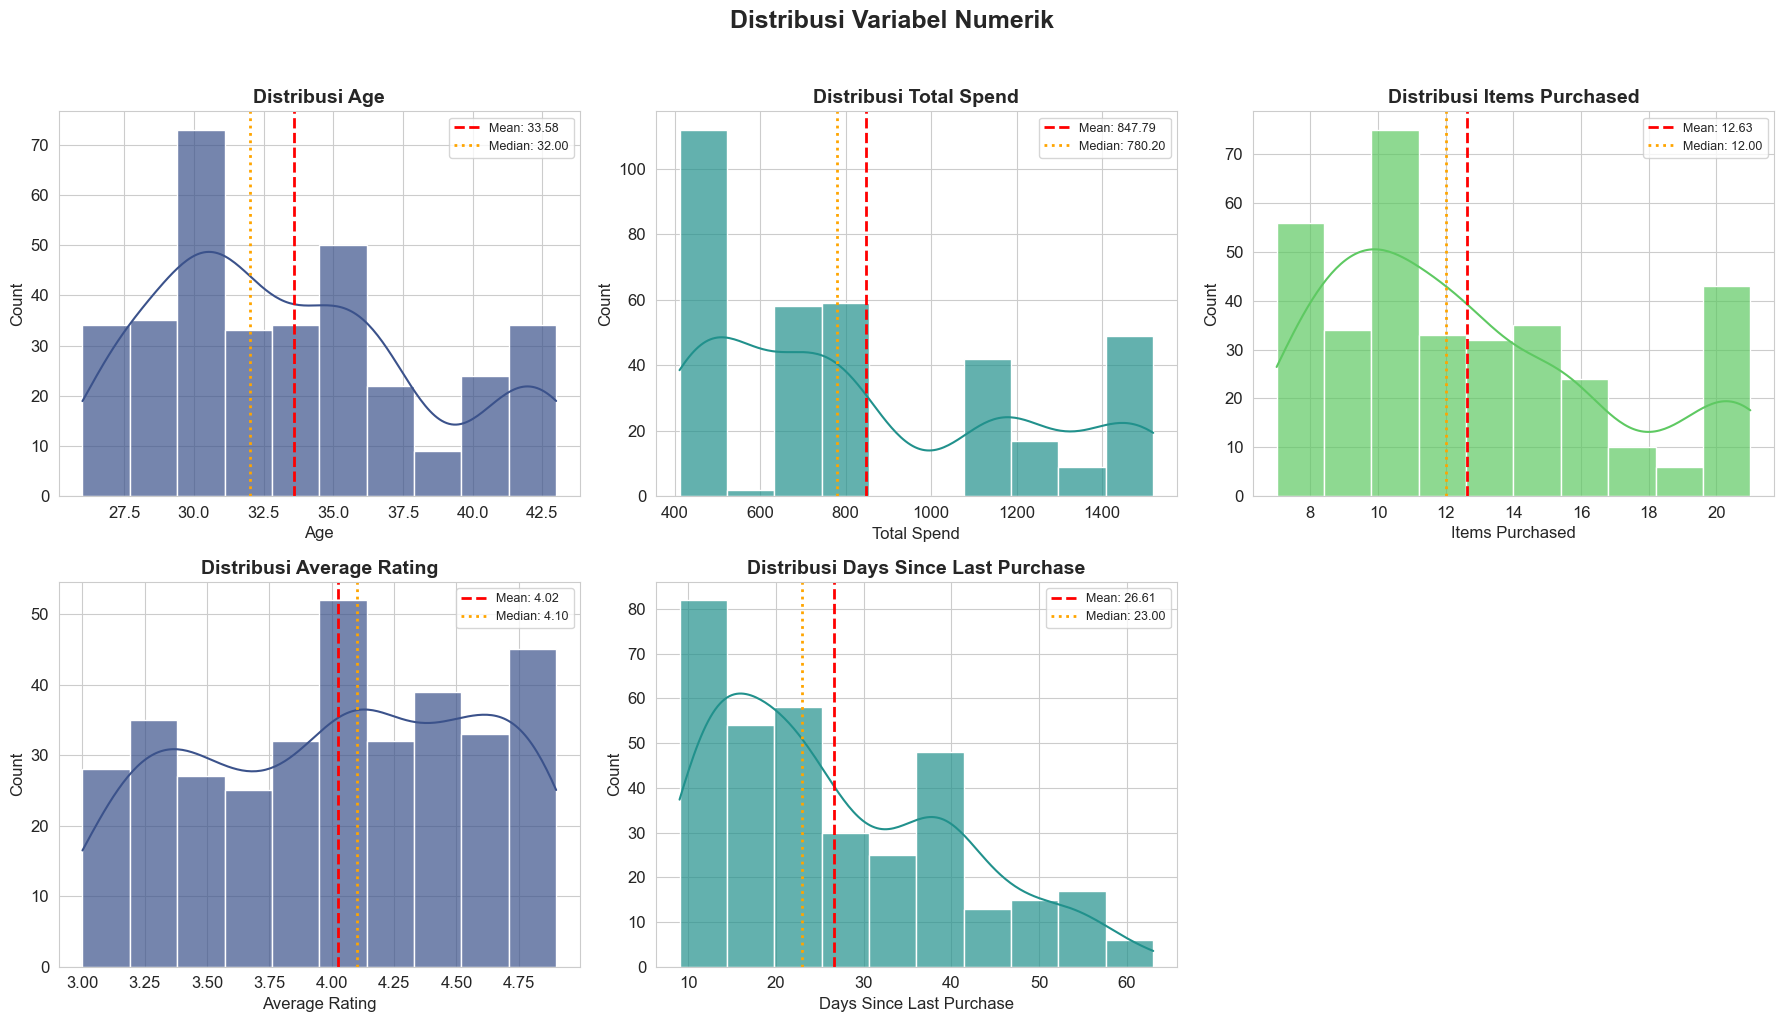

In [3]:
num_cols = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color=palette[i % 3], edgecolor='white', alpha=0.7)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle=':', linewidth=2, label=f'Median: {df[col].median():.2f}')
    ax.set_title(f'Distribusi {col}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)

axes[5].axis('off')
plt.suptitle('Distribusi Variabel Numerik', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_01_distribusi_numerik.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribusi Variabel Kategorikal

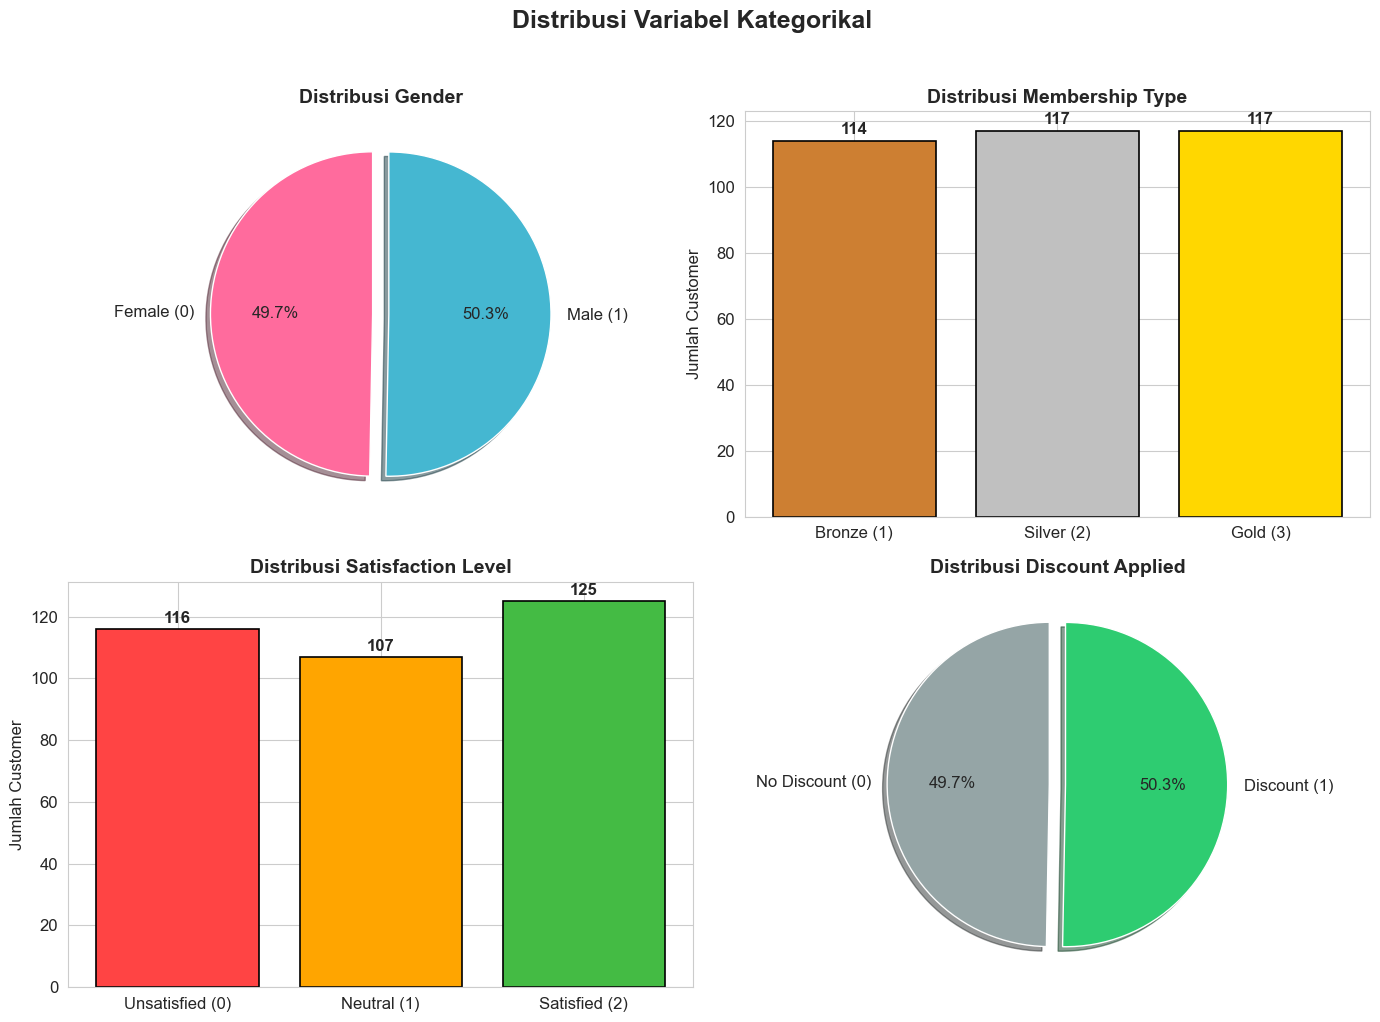

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
gender_labels = ['Female (0)', 'Male (1)']
gender_counts = df['Gender'].value_counts().sort_index()
axes[0, 0].pie(gender_counts, labels=gender_labels, autopct='%1.1f%%', colors=['#FF6B9D', '#45B7D1'],
               startangle=90, explode=(0.05, 0.05), shadow=True)
axes[0, 0].set_title('Distribusi Gender', fontsize=14, fontweight='bold')

# Membership Type
mem_labels = ['Bronze (1)', 'Silver (2)', 'Gold (3)']
mem_counts = df['Membership Type'].value_counts().sort_index()
colors_mem = ['#CD7F32', '#C0C0C0', '#FFD700']
bars = axes[0, 1].bar(mem_labels, mem_counts, color=colors_mem, edgecolor='black', linewidth=1.2)
for bar, count in zip(bars, mem_counts):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(count),
                    ha='center', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Distribusi Membership Type', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Jumlah Customer')

# Satisfaction Level
sat_labels = ['Unsatisfied (0)', 'Neutral (1)', 'Satisfied (2)']
sat_counts = df['Satisfaction Level'].value_counts().sort_index()
colors_sat = ['#FF4444', '#FFA500', '#44BB44']
bars2 = axes[1, 0].bar(sat_labels, sat_counts, color=colors_sat, edgecolor='black', linewidth=1.2)
for bar, count in zip(bars2, sat_counts):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(count),
                    ha='center', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Distribusi Satisfaction Level', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Jumlah Customer')

# Discount Applied
disc_labels = ['No Discount (0)', 'Discount (1)']
disc_counts = df['Discount Applied'].value_counts().sort_index()
axes[1, 1].pie(disc_counts, labels=disc_labels, autopct='%1.1f%%', colors=['#95a5a6', '#2ecc71'],
               startangle=90, explode=(0.05, 0.05), shadow=True)
axes[1, 1].set_title('Distribusi Discount Applied', fontsize=14, fontweight='bold')

plt.suptitle('Distribusi Variabel Kategorikal', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_distribusi_kategorikal.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 🔥 Heatmap Korelasi (Tugas Utama)

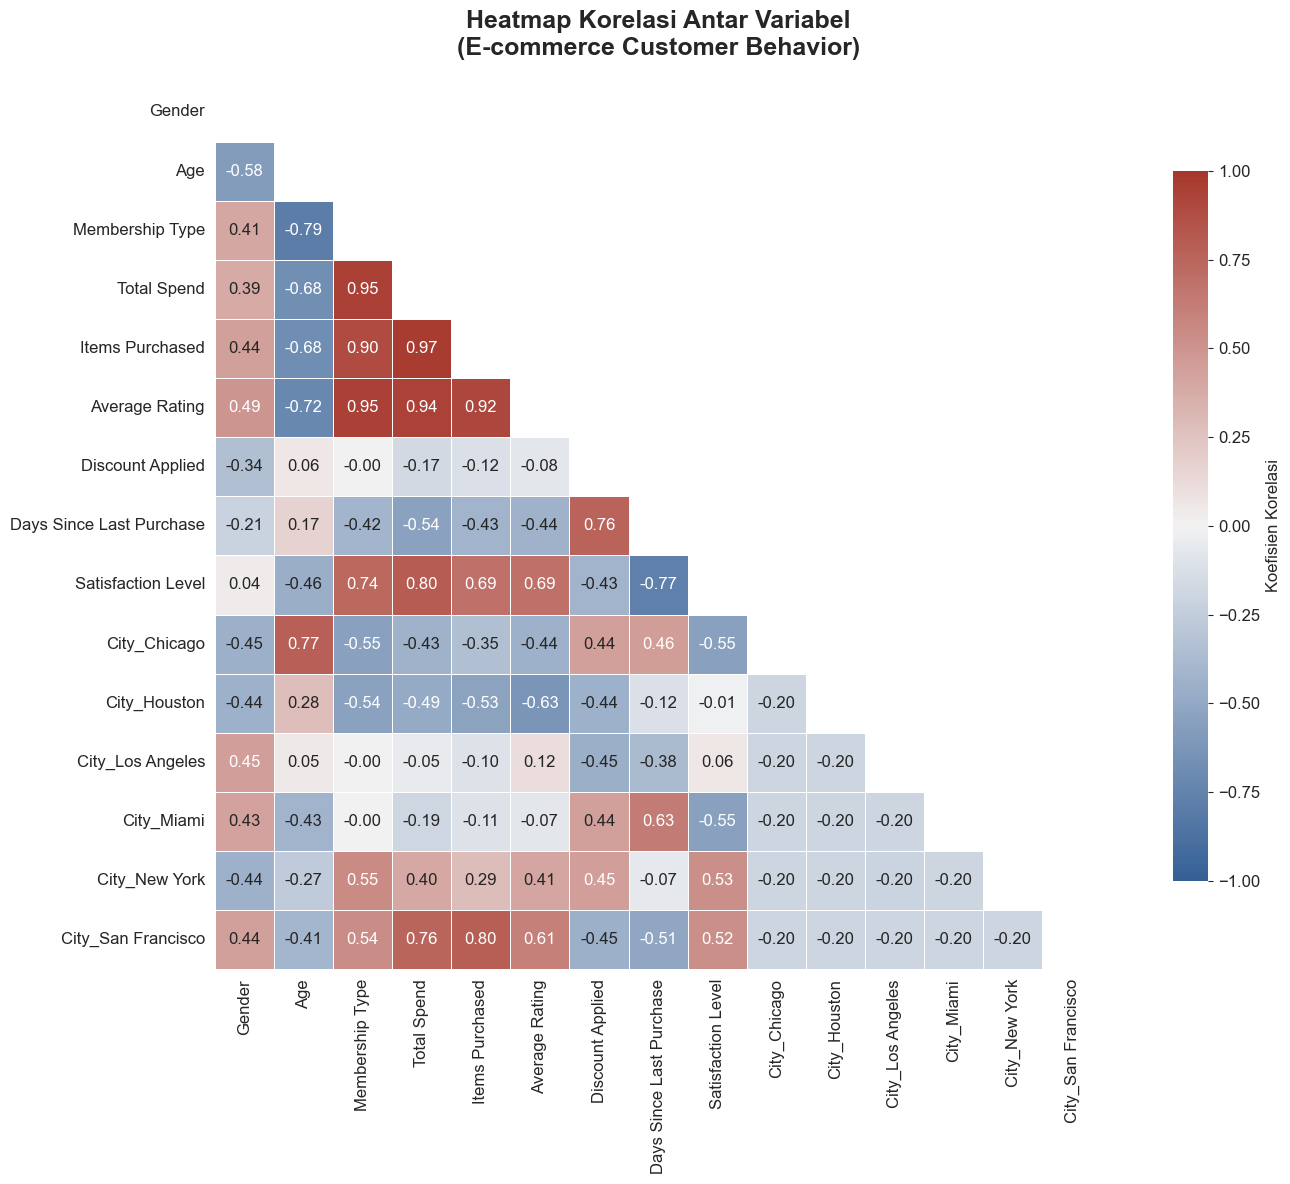


📌 Top 10 Korelasi Tertinggi (Absolut):
  Total Spend ↔ Items Purchased: 0.9723
  Membership Type ↔ Average Rating: 0.9498
  Membership Type ↔ Total Spend: 0.9453
  Average Rating ↔ Total Spend: 0.9412
  Items Purchased ↔ Average Rating: 0.9214
  Membership Type ↔ Items Purchased: 0.8963
  Satisfaction Level ↔ Total Spend: 0.7975
  Items Purchased ↔ City_San Francisco: 0.7959
  Membership Type ↔ Age: -0.7905
  City_Chicago ↔ Age: 0.7749


In [5]:
# Heatmap korelasi seluruh variabel numerik
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center='light', as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Heatmap Korelasi Antar Variabel\n(E-commerce Customer Behavior)', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz_03_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Tampilkan korelasi tertinggi
print("\n📌 Top 10 Korelasi Tertinggi (Absolut):")
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1.0]
corr_pairs = corr_pairs.abs().sort_values(ascending=False).drop_duplicates().head(10)
for idx, val in corr_pairs.items():
    actual = corr_matrix.loc[idx[0], idx[1]]
    print(f"  {idx[0]} ↔ {idx[1]}: {actual:.4f}")

## 6. Heatmap Korelasi (Variabel Utama Saja - Tanpa One-Hot City)

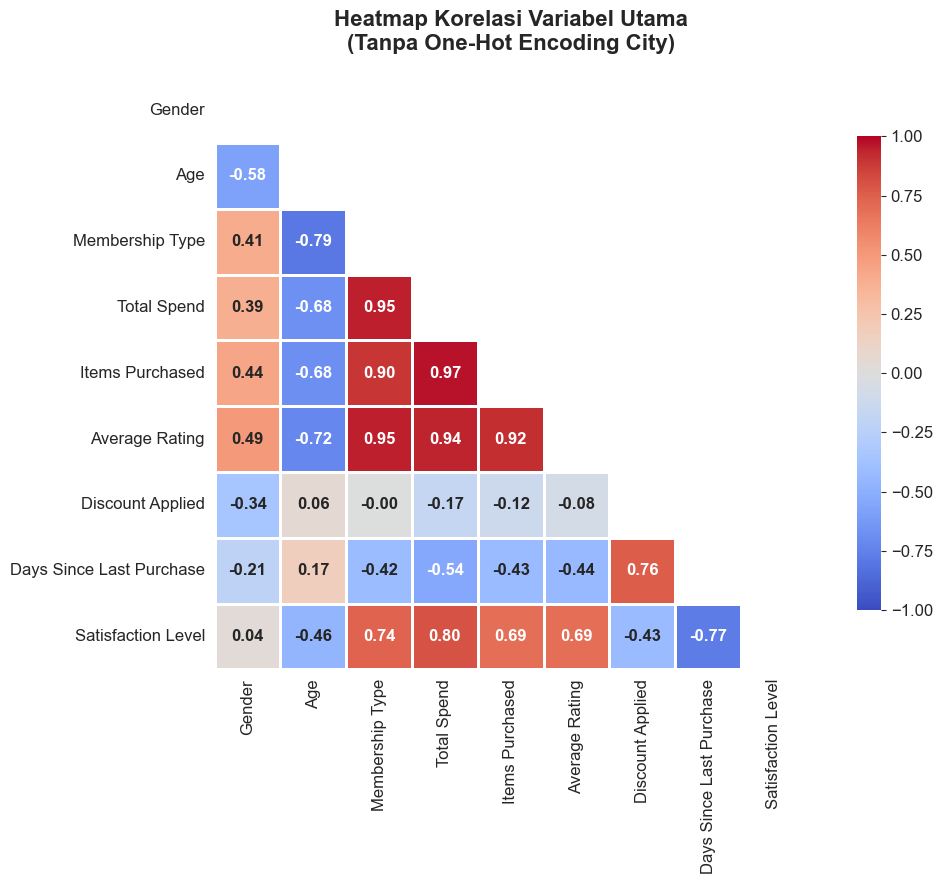

In [6]:
main_cols = ['Gender', 'Age', 'Membership Type', 'Total Spend', 'Items Purchased',
             'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level']
corr_main = df[main_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask2 = np.triu(np.ones_like(corr_main, dtype=bool))
sns.heatmap(corr_main, mask=mask2, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Heatmap Korelasi Variabel Utama\n(Tanpa One-Hot Encoding City)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz_04_heatmap_korelasi_utama.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 📊 Grafik Distribusi Membership (Tugas Utama)

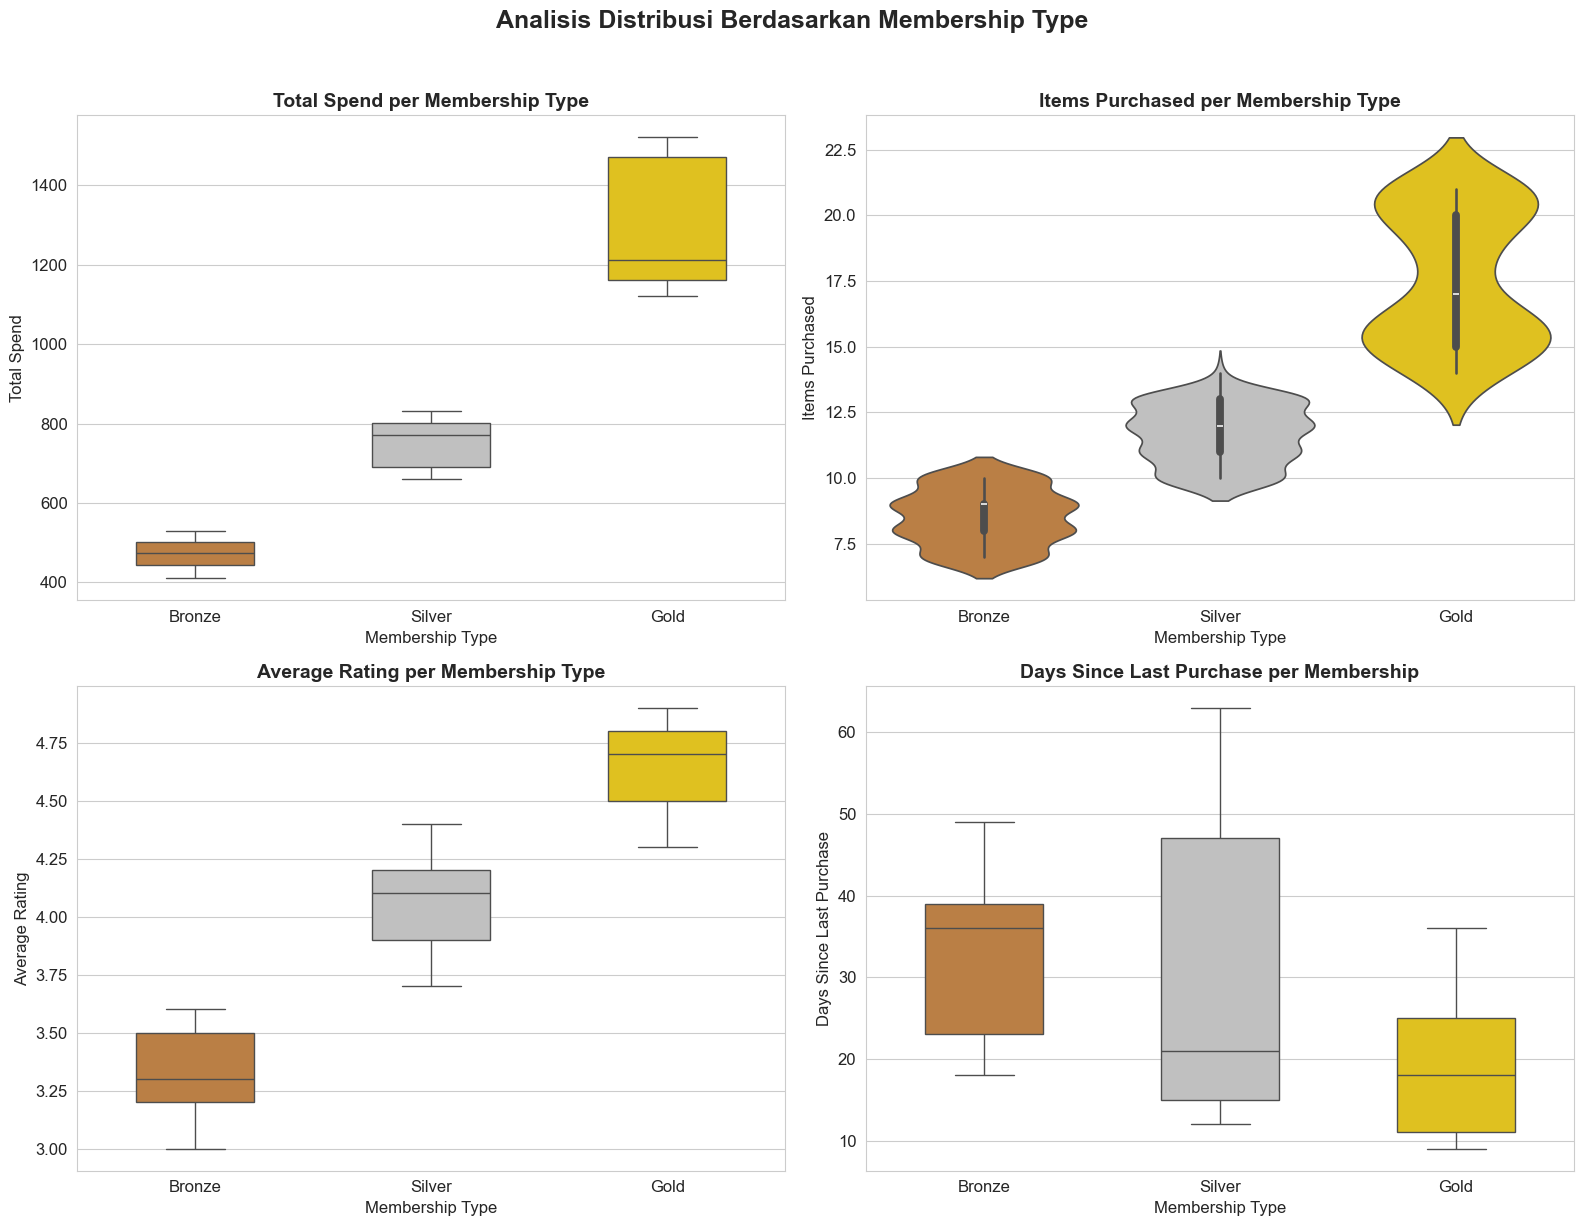


📊 Statistik per Membership Type:
                 Total Spend                  Items Purchased              Average Rating              Days Since Last Purchase              
                        mean   median     std            mean median   std           mean median   std                     mean median    std
Membership Label                                                                                                                             
Bronze                474.22   475.25   30.92            8.52    9.0  1.04           3.33    3.3  0.20                    31.78   36.0   9.50
Gold                 1311.14  1210.60  151.93           17.62   17.0  2.55           4.68    4.7  0.17                    17.94   18.0   7.54
Silver                748.43   770.20   60.59           11.66   12.0  1.11           4.05    4.1  0.17                    30.26   21.0  16.82


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
mem_map = {1: 'Bronze', 2: 'Silver', 3: 'Gold'}
df['Membership Label'] = df['Membership Type'].map(mem_map)
colors_m = {'Bronze': '#CD7F32', 'Silver': '#C0C0C0', 'Gold': '#FFD700'}
order_m = ['Bronze', 'Silver', 'Gold']

# 7a. Total Spend per Membership
sns.boxplot(data=df, x='Membership Label', y='Total Spend', order=order_m,
            palette=colors_m, ax=axes[0, 0], width=0.5)
axes[0, 0].set_title('Total Spend per Membership Type', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Membership Type')

# 7b. Items Purchased per Membership
sns.violinplot(data=df, x='Membership Label', y='Items Purchased', order=order_m,
               palette=colors_m, ax=axes[0, 1], inner='box')
axes[0, 1].set_title('Items Purchased per Membership Type', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Membership Type')

# 7c. Average Rating per Membership
sns.boxplot(data=df, x='Membership Label', y='Average Rating', order=order_m,
            palette=colors_m, ax=axes[1, 0], width=0.5)
axes[1, 0].set_title('Average Rating per Membership Type', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Membership Type')

# 7d. Days Since Last Purchase per Membership
sns.boxplot(data=df, x='Membership Label', y='Days Since Last Purchase', order=order_m,
            palette=colors_m, ax=axes[1, 1], width=0.5)
axes[1, 1].set_title('Days Since Last Purchase per Membership', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Membership Type')

plt.suptitle('Analisis Distribusi Berdasarkan Membership Type', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_05_distribusi_membership.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistik per membership
print("\n📊 Statistik per Membership Type:")
stats = df.groupby('Membership Label')[['Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']].agg(['mean', 'median', 'std']).round(2)
print(stats.to_string())

## 8. Membership Type vs Satisfaction Level (Cross Analysis)

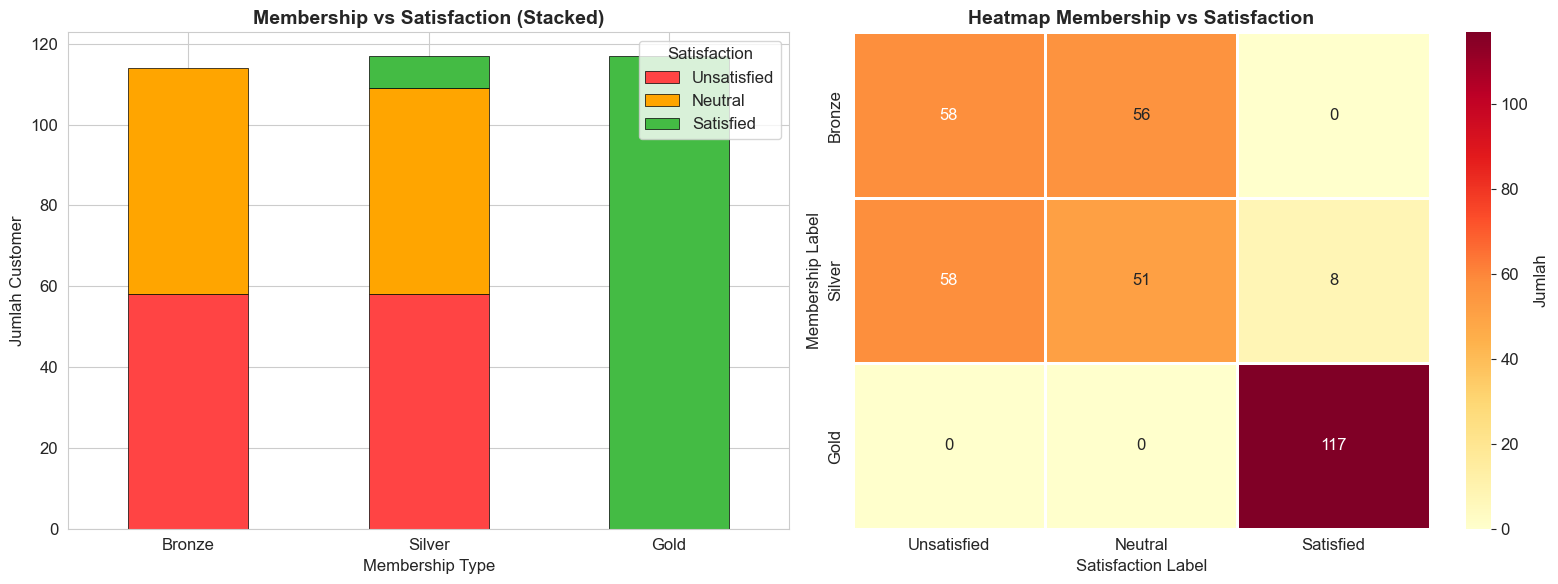


📌 Insight Penting:
- Gold member: 100% Satisfied (117/117)
- Bronze member: 0% Satisfied, mayoritas Neutral & Unsatisfied
- Silver member: mayoritas Neutral & Unsatisfied, sedikit Satisfied


In [8]:
sat_map = {0: 'Unsatisfied', 1: 'Neutral', 2: 'Satisfied'}
df['Satisfaction Label'] = df['Satisfaction Level'].map(sat_map)

ct = pd.crosstab(df['Membership Label'], df['Satisfaction Label'])
ct = ct[['Unsatisfied', 'Neutral', 'Satisfied']]
ct_reindex = ct.reindex(['Bronze', 'Silver', 'Gold'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
ct_reindex.plot(kind='bar', stacked=True, ax=axes[0], color=['#FF4444', '#FFA500', '#44BB44'],
                edgecolor='black', linewidth=0.5)
axes[0].set_title('Membership vs Satisfaction (Stacked)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Membership Type')
axes[0].set_ylabel('Jumlah Customer')
axes[0].legend(title='Satisfaction')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Heatmap crosstab
sns.heatmap(ct_reindex, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            linewidths=1, cbar_kws={'label': 'Jumlah'})
axes[1].set_title('Heatmap Membership vs Satisfaction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_06_membership_vs_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight Penting:")
print("- Gold member: 100% Satisfied (117/117)")
print("- Bronze member: 0% Satisfied, mayoritas Neutral & Unsatisfied")
print("- Silver member: mayoritas Neutral & Unsatisfied, sedikit Satisfied")

## 9. Pairplot Variabel Utama

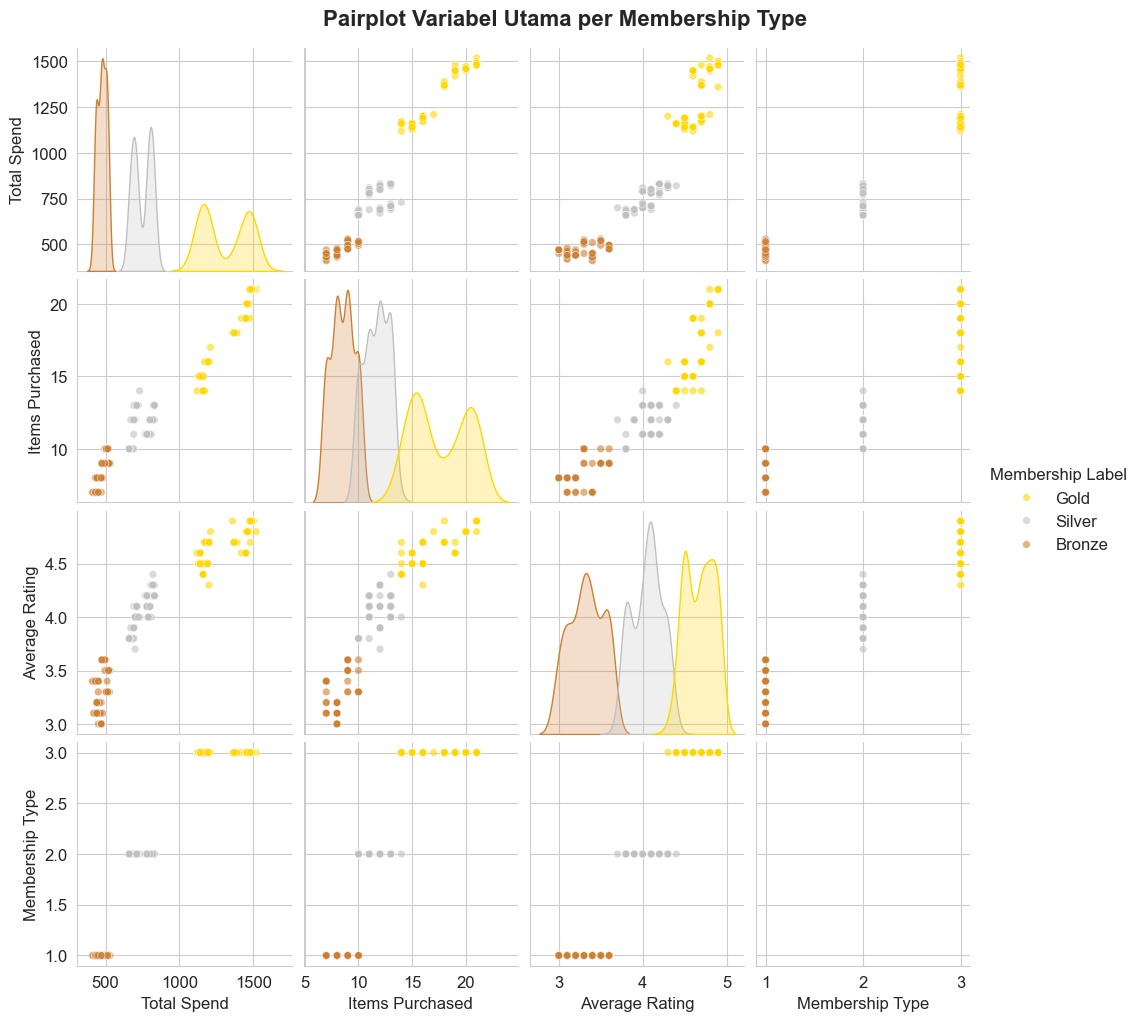

In [9]:
pair_cols = ['Total Spend', 'Items Purchased', 'Average Rating', 'Membership Type']
g = sns.pairplot(df[pair_cols + ['Membership Label']], hue='Membership Label',
                 palette=colors_m, diag_kind='kde', height=2.5,
                 plot_kws={'alpha': 0.6, 's': 30})
g.figure.suptitle('Pairplot Variabel Utama per Membership Type', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('viz_07_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Analisis Usia per Membership & Satisfaction

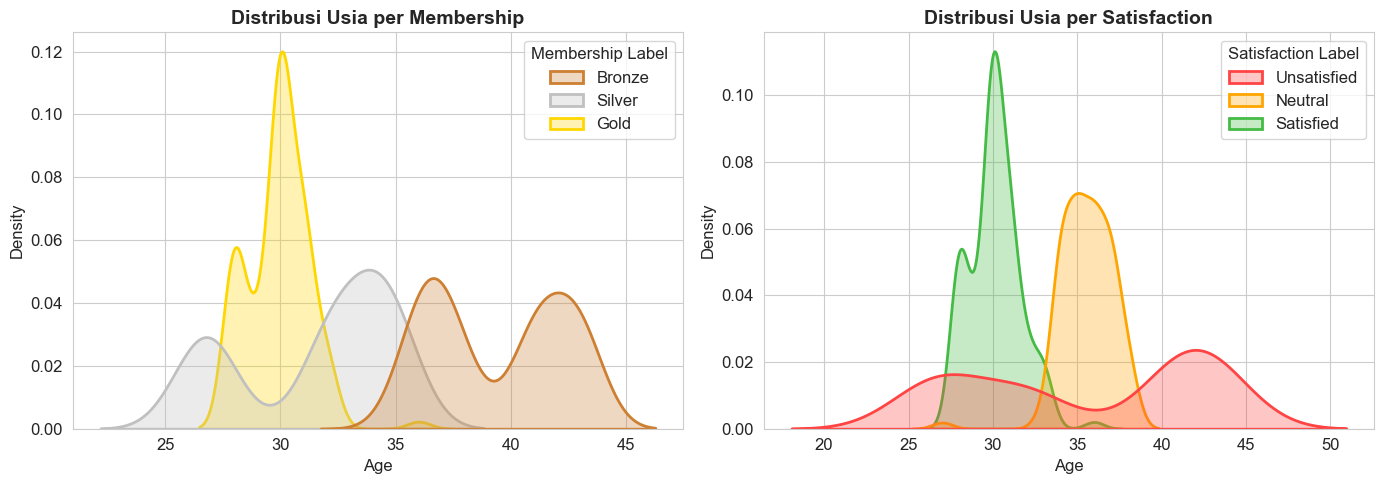

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='Age', hue='Membership Label', hue_order=order_m,
            palette=colors_m, fill=True, alpha=0.3, ax=axes[0], linewidth=2)
axes[0].set_title('Distribusi Usia per Membership', fontsize=14, fontweight='bold')

sns.kdeplot(data=df, x='Age', hue='Satisfaction Label', hue_order=['Unsatisfied', 'Neutral', 'Satisfied'],
            palette=['#FF4444', '#FFA500', '#44BB44'], fill=True, alpha=0.3, ax=axes[1], linewidth=2)
axes[1].set_title('Distribusi Usia per Satisfaction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_08_distribusi_usia.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Scatter Plot: Total Spend vs Items Purchased

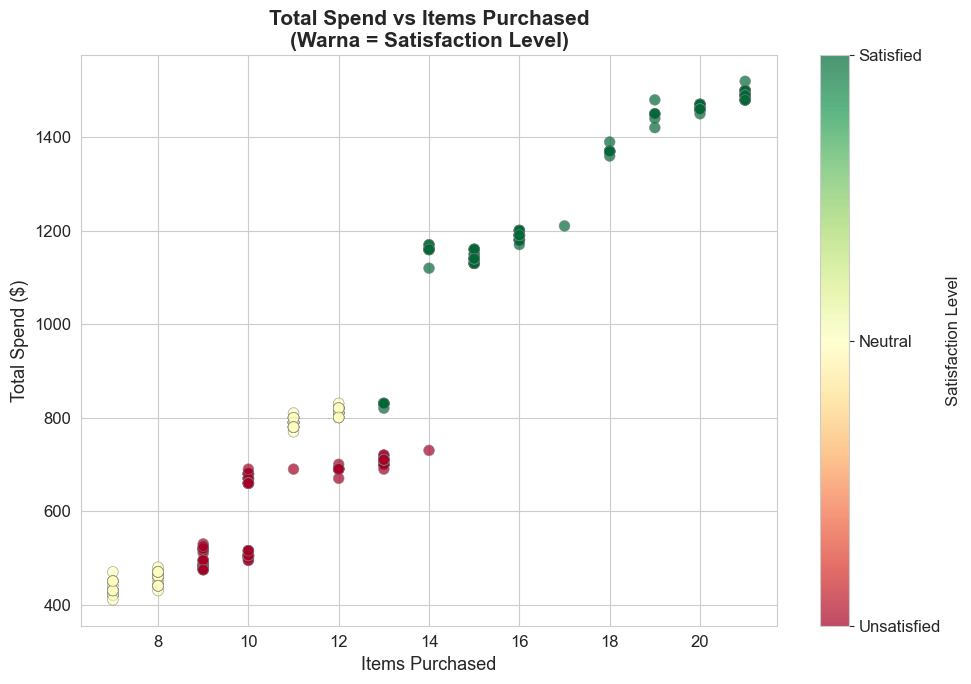


📌 Korelasi Total Spend vs Items Purchased: 0.9723
   → Korelasi positif sangat kuat, semakin banyak item dibeli, semakin tinggi total belanja


In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df['Items Purchased'], df['Total Spend'], c=df['Satisfaction Level'],
                     cmap='RdYlGn', s=60, alpha=0.7, edgecolor='gray', linewidth=0.5)
cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1, 2])
cbar.set_ticklabels(['Unsatisfied', 'Neutral', 'Satisfied'])
cbar.set_label('Satisfaction Level')
ax.set_xlabel('Items Purchased', fontsize=13)
ax.set_ylabel('Total Spend ($)', fontsize=13)
ax.set_title('Total Spend vs Items Purchased\n(Warna = Satisfaction Level)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_09_scatter_spend_items.png', dpi=150, bbox_inches='tight')
plt.show()

corr_val = df['Total Spend'].corr(df['Items Purchased'])
print(f"\n📌 Korelasi Total Spend vs Items Purchased: {corr_val:.4f}")
print("   → Korelasi positif sangat kuat, semakin banyak item dibeli, semakin tinggi total belanja")

## 12. Ringkasan & Kesimpulan EDA

In [12]:
print("=" * 60)
print("         📋 RINGKASAN HASIL EDA")
print("=" * 60)

print("""
1. DATASET
   - Data awal: 350 baris, 11 kolom
   - Setelah cleaning: 348 baris, 15 kolom (2 baris dihapus karena missing value pada Satisfaction Level)

2. DISTRIBUSI DATA
   - Gender: seimbang (50% Female, 50% Male)
   - Membership: hampir merata (Bronze≈116, Silver≈117, Gold≈117)
   - Kota: distribusi merata (~58 per kota)
   - Satisfaction: Satisfied(125) > Unsatisfied(116) > Neutral(107)

3. KORELASI UTAMA
   - Total Spend ↔ Items Purchased: korelasi positif sangat kuat
   - Total Spend ↔ Membership Type: korelasi positif kuat
   - Average Rating ↔ Membership Type: korelasi positif
   - Satisfaction Level ↔ Membership Type: korelasi positif kuat

4. INSIGHT MEMBERSHIP
   - Gold: Total Spend tertinggi, rating tertinggi, 100% Satisfied
   - Silver: Total Spend menengah, campuran kepuasan
   - Bronze: Total Spend terendah, 0% Satisfied

5. REKOMENDASI UNTUK MODEL KNN
   - Fitur paling berpengaruh: Membership Type, Total Spend, Items Purchased, Average Rating
   - Target: Satisfaction Level (3 kelas: Unsatisfied, Neutral, Satisfied)
   - Data sudah clean & encoded, siap untuk di-split dan digunakan oleh ML Engineer (Vian)
""")

# Bersihkan kolom tambahan
df.drop(columns=['Membership Label', 'Satisfaction Label'], inplace=True, errors='ignore')
print("✅ EDA selesai! Data siap untuk tahap selanjutnya (KNN oleh Vian).")

         📋 RINGKASAN HASIL EDA

1. DATASET
   - Data awal: 350 baris, 11 kolom
   - Setelah cleaning: 348 baris, 15 kolom (2 baris dihapus karena missing value pada Satisfaction Level)

2. DISTRIBUSI DATA
   - Gender: seimbang (50% Female, 50% Male)
   - Membership: hampir merata (Bronze≈116, Silver≈117, Gold≈117)
   - Kota: distribusi merata (~58 per kota)
   - Satisfaction: Satisfied(125) > Unsatisfied(116) > Neutral(107)

3. KORELASI UTAMA
   - Total Spend ↔ Items Purchased: korelasi positif sangat kuat
   - Total Spend ↔ Membership Type: korelasi positif kuat
   - Average Rating ↔ Membership Type: korelasi positif
   - Satisfaction Level ↔ Membership Type: korelasi positif kuat

4. INSIGHT MEMBERSHIP
   - Gold: Total Spend tertinggi, rating tertinggi, 100% Satisfied
   - Silver: Total Spend menengah, campuran kepuasan
   - Bronze: Total Spend terendah, 0% Satisfied

5. REKOMENDASI UNTUK MODEL KNN
   - Fitur paling berpengaruh: Membership Type, Total Spend, Items Purchased, Average 